1. KaggleHub 최초 다운로드 경로: C:\Users\student\.cache\kagglehub\datasets\utkarshsaxenadn\car-vs-bike-classification-dataset\versions\1
2. 🎯 자동 매칭된 최종 데이터셋 경로: C:\Users\student\.cache\kagglehub\datasets\utkarshsaxenadn\car-vs-bike-classification-dataset\versions\1\Car-Bike-Dataset
3. 📂 발견된 클래스 폴더 목록 (Car, Bike): ['Bike', 'Car']
Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 [1단계] 전이 학습(상위 헤드 레이어만 학습) 시작...
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 455ms/step - accuracy: 0.9278 - loss: 0.1877 - val_accuracy: 0.9862 - val_loss: 0.0447
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 427ms/step - accuracy: 0.9831 - loss: 0.0572 - val_accuracy: 0.9887 - val_loss: 0.0326
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 428ms/step - accuracy: 0.9856 - loss: 0.0497 - val_accuracy: 0.9900 - val_loss: 0.0261
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 440ms/step - 

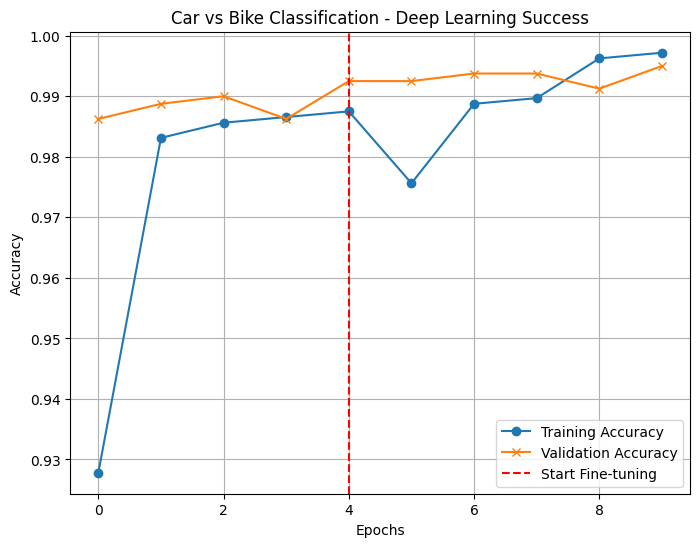

In [6]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
import kagglehub

# ==========================================
# 1. 데이터셋 다운로드 및 완벽한 경로 자동 정밀 탐색
# ==========================================
download_path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")
print("1. KaggleHub 최초 다운로드 경로:", download_path)

# 폴더가 한 겹이든 두 겹이든, 'Car' 폴더가 있는 실제 디렉토리를 자동으로 추적합니다.
DATASET_DIR = download_path
for root, dirs, files in os.walk(download_path):
    if 'Car' in dirs and 'Bike' in dirs:
        DATASET_DIR = root
        break

print("2. 🎯 자동 매칭된 최종 데이터셋 경로:", DATASET_DIR)
print("3. 📂 발견된 클래스 폴더 목록 (Car, Bike):", os.listdir(DATASET_DIR))

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# ==========================================
# 2. 데이터 불러오기 및 분할 (Train / Validation)
# ==========================================
# 상위 경로가 완벽히 잡혔으므로 여기서 에러 없이 2개의 클래스(Car, Bike)를 정상 인식합니다.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'  # Car: 0, Bike: 1
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 데이터 연산 속도 가속화 설정
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. 데이터 증강 (Data Augmentation) 레이어
# ==========================================
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),     # 좌우 반전
    layers.RandomRotation(0.1),        # 살짝 회전
    layers.RandomZoom(0.1),            # 살짝 확대/축소
])

# ==========================================
# 4. 전이 학습 (Transfer Learning) 단계
# ==========================================
# 기성 대형 모델인 MobileNetV2 로드 (ImageNet 가중치 탑재)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# 베이스 모델의 핵심 가중치들을 임시로 단단히 고정(동결)
base_model.trainable = False

# 커스텀 분류층 레이어 결합
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)                                # 데이터 증강 통과
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)   # 모델 규격에 맞춰 -1 ~ 1 스케일링
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)                      # 차원 압축
outputs = layers.Dense(1, activation='sigmoid')(x)           # 이진 분류 아웃풋 (0 또는 1)
model = models.Model(inputs, outputs)

# 전이 학습 컴파일 (기본 학습률 0.001 적용)
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n🚀 [1단계] 전이 학습(상위 헤드 레이어만 학습) 시작...")
history_tl = model.fit(train_ds, epochs=5, validation_data=val_ds)

# ==========================================
# 5. 파인 튜닝 (Fine-tuning) 단계
# ==========================================
# 고정했던 베이스 모델의 고정을 완전히 해제
base_model.trainable = True

# 모델의 전체 154개 레이어 중 초기 특징(선, 면 등)을 잡는 하위 100개 레이어는 다시 고정
for layer in base_model.layers[:100]:
    layer.trainable = False

# ⚠️ 가중치가 망가지는 것을 막기 위해 학습률을 10배 낮춥니다 (0.001 -> 0.0001)
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n🚀 [2단계] 파인 튜닝(상위 결합 레이어 미세 조정) 시작...")
history_ft = model.fit(train_ds, epochs=5, validation_data=val_ds)

# ==========================================
# 6. 최종 학습 결과 시각화 (그래프 출력)
# ==========================================
# 전이 학습(5에포크)과 파인 튜닝(5에포크) 결과를 합쳐서 그래프를 그립니다.
acc = history_tl.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.figure(figsize=(8, 6))
plt.plot(acc, label='Training Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='x')
plt.axvline(x=4, color='r', linestyle='--', label='Start Fine-tuning') # 파인 튜닝 시작 시점 표시
plt.title('Car vs Bike Classification - Deep Learning Success')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


C:\Users\student\AppData\Local\Temp\ipykernel_14652\1261256475.py:46: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


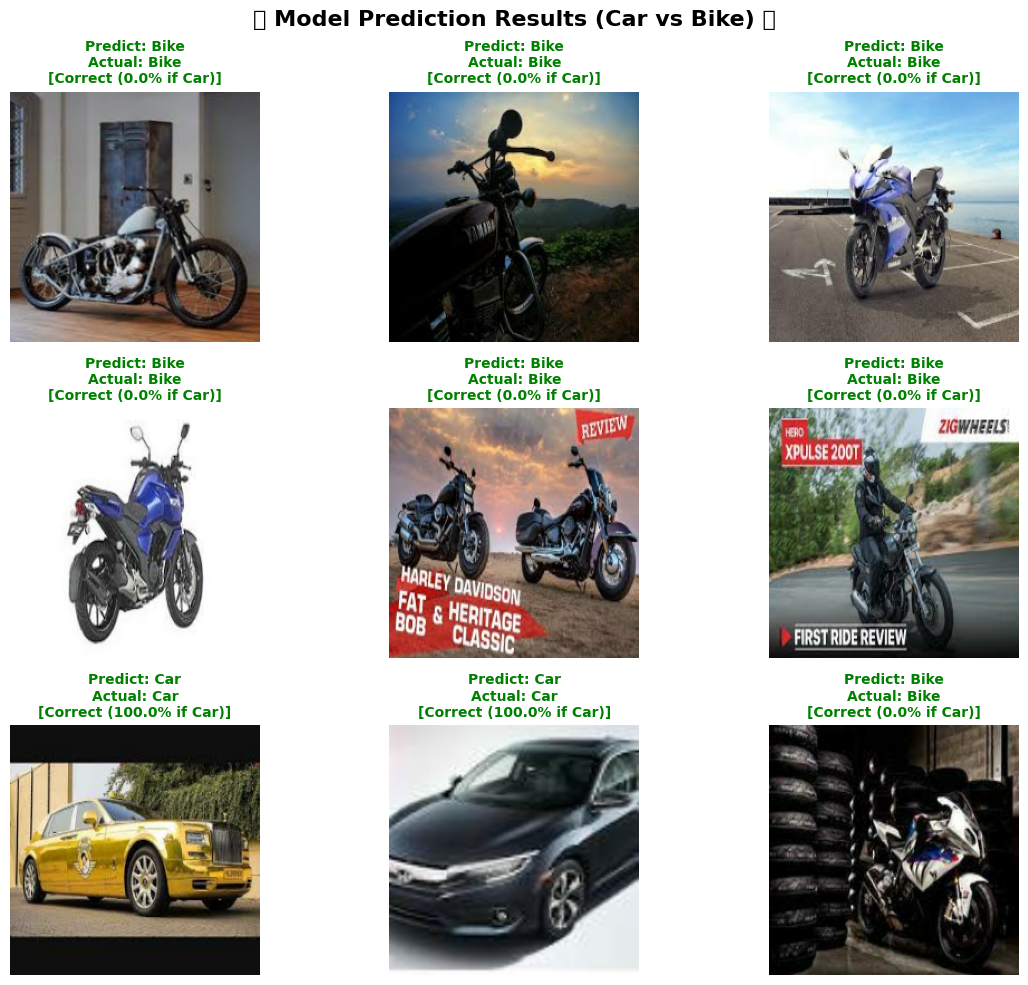

In [ ]:
import numpy as np

# ==========================================
# 7. 모델의 실제 분류 결과 시각화 (자동차 vs 오토바이)
# ==========================================
# 검증 데이터셋에서 이미지 1개 배치를 가져옵니다 (32장)
image_batch, label_batch = next(iter(val_ds))

# 모델에게 이 이미지들이 무엇인지 예측을 시킵니다.
predictions = model.predict(image_batch)

# 클래스 이름 매핑 (image_dataset_from_directory의 기본 정렬 순서)
# 0번 인덱스가 Bike, 1번 인덱스가 Car로 잡힙니다. (폴더 알파벳 순)
class_names = ['Bike', 'Car']

plt.figure(figsize=(12, 10))
plt.suptitle("🚨 Model Prediction Results (Car vs Bike) 🚨", fontsize=16, fontweight='bold')

# 배치 안에서 앞의 9장만 화면에 출력합니다.
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    
    # 텐서플로우 이미지를 다시 화면에 그릴 수 있는 형태로 변환
    img = image_batch[i].numpy().astype("uint8")
    plt.imshow(img)
    
    # 실제 정답과 모델이 예측한 값 확률 추출
    actual_label = class_names[int(label_batch[i][0])]
    
    # 시그모이드 출력이므로 0.5보다 크면 1(Car), 작으면 0(Bike)
    pred_prob = predictions[i][0]
    pred_label = class_names[1 if pred_prob > 0.5 else 0]
    
    # 맞췄으면 초록색, 틀렸으면 빨간색으로 글씨 표시
    if pred_label == actual_label:
        title_color = 'green'
        result_text = f"Correct ({pred_prob*100:.1f}% if Car)"
    else:
        title_color = 'red'
        result_text = f"Wrong ({pred_prob*100:.1f}% if Car)"
        
    plt.title(f"Predict: {pred_label}\nActual: {actual_label}\n[{result_text}]", 
              color=title_color, fontsize=10, fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()

yolo를 GPU로 해볼려고 했는데 자꾸 잘 안되서 시간만 날렸네요..ㅎㅎ